# Statistical Analysis & Feature Selection

**Project:** Customer Churn Prediction & Business Intelligence System

This notebook provides statistical evidence for relationships with customer churn and prepares a defensible feature set for Group 4.

### Objectives
- Analyze categorical variables against churn using the Chi-square test.
- Measure categorical association strength using Cramér's V.
- Analyze numerical variables using Welch's t-test and Mann–Whitney U test.
- Measure numerical effect size using Cohen's d.
- Apply multiple-testing correction.
- Check multicollinearity using correlation and VIF.
- Rank features using Mutual Information.
- Produce feature-selection results and a final Group 4 feature list.

> **Target:** `Churn Value`  
> `1 = Churned`, `0 = Retained`


In [1]:
# 1. Import libraries

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Locate the project and load the feature-engineered dataset

In [2]:
# 2. Locate repository root and define paths

current_path = Path.cwd().resolve()

def find_repo_root(start_path):
    for path in [start_path] + list(start_path.parents):
        expected_file = (
            path
            / "Feature Engineering & Statistical Analysis"
            / "outputs"
            / "customer_churn_feature_engineered.csv"
        )
        if expected_file.exists():
            return path

    raise FileNotFoundError(
        "Could not find 'customer_churn_feature_engineered.csv'. "
        "Run feature_engineering.ipynb first and make sure this notebook "
        "is inside the project repository."
    )

repo_root = find_repo_root(current_path)

group3_dir = repo_root / "Feature Engineering & Statistical Analysis"
output_dir = group3_dir / "outputs"
figures_dir = group3_dir / "figures"

output_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

input_path = output_dir / "customer_churn_feature_engineered.csv"

print("Repository root:", repo_root)
print("Input dataset  :", input_path)
print("Output folder  :", output_dir)

Repository root: D:\DS intern\Task\Group\Week 05\Customer-Churn-Prediction-Business-Intelligence-System
Input dataset  : D:\DS intern\Task\Group\Week 05\Customer-Churn-Prediction-Business-Intelligence-System\Feature Engineering & Statistical Analysis\outputs\customer_churn_feature_engineered.csv
Output folder  : D:\DS intern\Task\Group\Week 05\Customer-Churn-Prediction-Business-Intelligence-System\Feature Engineering & Statistical Analysis\outputs


In [3]:
# 3. Load feature-engineered dataset

df = pd.read_csv(input_path)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Dataset loaded: 7,043 rows × 29 columns


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Is_New_Customer,Tenure_Band,Is_Month_to_Month,High_Monthly_Charge,Fiber_Monthly_Risk,New_High_Spend,New_Monthly_Customer,Support_Service_Count,Security_Tech_Bundle
0,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,0,53.85,108.15,1,1,0-6,1,0,0,0,1,2,0
1,Female,0,0,1,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,0,70.70,151.65,1,1,0-6,1,1,1,1,1,0,0
2,Female,0,0,1,8,1,1,Fiber optic,0,0,1,0,1,1,Month-to-month,1,0,99.65,820.50,1,1,7-12,1,1,1,1,1,1,0
3,Female,0,1,1,28,1,1,Fiber optic,0,0,1,1,1,1,Month-to-month,1,0,104.80,3046.05,1,0,25-48,1,1,1,0,0,2,0
4,Male,0,0,1,49,1,1,Fiber optic,0,1,1,0,1,1,Month-to-month,1,1,103.70,5036.30,1,0,49+,1,1,1,0,0,2,0


## 2. Statistical-analysis validation

In [4]:
# 4. Validate target and dataset

if "Churn Value" not in df.columns:
    raise ValueError("Target column 'Churn Value' is missing.")

print("Shape:", df.shape)
print("Missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

target_summary = pd.DataFrame({
    "Count": df["Churn Value"].value_counts().sort_index(),
    "Percentage": (
        df["Churn Value"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

display(target_summary)

Shape: (7043, 29)
Missing values: 0
Duplicate rows: 26


,Count,Percentage
Churn Value,,
0,5174,73.46
1,1869,26.54


## 3. Define categorical and numerical variables

Binary indicators are treated as categorical variables for the Chi-square analysis. Continuous/count variables are tested separately.

In [5]:
# 5. Define feature groups

categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Is_New_Customer",
    "Tenure_Band",
    "Is_Month_to_Month",
    "High_Monthly_Charge",
    "Fiber_Monthly_Risk",
    "New_High_Spend",
    "New_Monthly_Customer",
    "Security_Tech_Bundle"
]

numerical_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Support_Service_Count"
]

categorical_features = [
    col for col in categorical_features if col in df.columns
]

numerical_features = [
    col for col in numerical_features if col in df.columns
]

print("Categorical features:", len(categorical_features))
print("Numerical features  :", len(numerical_features))

Categorical features: 24
Numerical features  : 4


# 4. Categorical variables vs churn

For each categorical feature:

- **Chi-square test** checks whether the feature and churn are statistically associated.
- **Cramér's V** measures the strength of the association.
- A Benjamini–Hochberg False Discovery Rate correction is applied because many hypotheses are tested.

A small p-value does **not** prove causation.

In [6]:
# 6. Helper functions

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table, correction=False)[0]
    n = contingency_table.to_numpy().sum()
    rows, cols = contingency_table.shape

    denominator = min(rows - 1, cols - 1)

    if denominator <= 0 or n == 0:
        return np.nan

    return np.sqrt(chi2 / (n * denominator))


def interpret_cramers_v(value):
    if pd.isna(value):
        return "Not available"
    if value < 0.10:
        return "Very weak"
    if value < 0.20:
        return "Weak"
    if value < 0.40:
        return "Moderate"
    return "Strong"


def bh_adjust(p_values):
    # Benjamini-Hochberg FDR-adjusted p-values
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)

    order = np.argsort(p_values)
    ranked = p_values[order]

    adjusted_ranked = ranked * n / np.arange(1, n + 1)

    # Ensure monotonicity from largest rank backwards
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted_ranked = np.clip(adjusted_ranked, 0, 1)

    adjusted = np.empty(n, dtype=float)
    adjusted[order] = adjusted_ranked

    return adjusted

In [7]:
# 7. Run Chi-square tests

chi_square_rows = []
category_churn_rows = []

for feature in categorical_features:

    table = pd.crosstab(df[feature], df["Churn Value"])

    chi2, p_value, dof, expected = chi2_contingency(table)
    v = cramers_v(table)

    chi_square_rows.append({
        "Feature": feature,
        "Chi_Square": chi2,
        "Degrees_of_Freedom": dof,
        "P_Value": p_value,
        "Cramers_V": v,
        "Association_Strength": interpret_cramers_v(v),
        "Minimum_Expected_Count": float(expected.min()),
        "Expected_Count_Assumption_OK": bool((expected >= 5).all())
    })

    # Descriptive churn rate for every category/value
    grouped = (
        df.groupby(feature, dropna=False)["Churn Value"]
        .agg(["count", "mean"])
        .reset_index()
    )

    for _, row in grouped.iterrows():
        category_churn_rows.append({
            "Feature": feature,
            "Category": row[feature],
            "Customer_Count": int(row["count"]),
            "Churn_Rate_Percent": round(float(row["mean"]) * 100, 2)
        })


chi_square_results = pd.DataFrame(chi_square_rows)

chi_square_results["FDR_Adjusted_P_Value"] = bh_adjust(
    chi_square_results["P_Value"].values
)

chi_square_results["Statistically_Significant_FDR_0.05"] = (
    chi_square_results["FDR_Adjusted_P_Value"] < 0.05
)

chi_square_results = chi_square_results.sort_values(
    by="Cramers_V",
    ascending=False
).reset_index(drop=True)

category_churn_rates = pd.DataFrame(category_churn_rows)

display(chi_square_results.round(6))

,Feature,Chi_Square,Degrees_of_Freedom,P_Value,Cramers_V,Association_Strength,Minimum_Expected_Count,Expected_Count_Assumption_OK,FDR_Adjusted_P_Value,Statistically_Significant_FDR_0.05
0,Fiber_Monthly_Risk,1230.239057,1,0.000000,0.418292,Strong,564.707085,True,0.000000,True
1,Contract,1184.596572,2,0.000000,0.410116,Strong,390.889820,True,0.000000,True
2,Is_Month_to_Month,1153.971661,1,0.000000,0.405103,Strong,840.691751,True,0.000000,True
3,Tenure_Band,927.329275,4,0.000000,0.362859,Moderate,187.085759,True,0.000000,True
4,New_Monthly_Customer,876.960929,1,0.000000,0.353224,Moderate,529.147522,True,0.000000,True
5,New_High_Spend,855.531678,1,0.000000,0.349027,Moderate,221.318472,True,0.000000,True
6,Internet Service,732.309590,2,0.000000,0.322455,Moderate,404.954423,True,0.000000,True
7,Is_New_Customer,708.782740,1,0.000000,0.317580,Moderate,580.098538,True,0.000000,True
8,Dependents,433.734379,1,0.000000,0.248542,Moderate,431.756780,True,0.000000,True
9,Payment Method,309.348557,1,0.000000,0.209902,Moderate,813.624024,True,0.000000,True


In [8]:
# 8. Display strongest categorical relationships

display(
    chi_square_results[
        [
            "Feature",
            "FDR_Adjusted_P_Value",
            "Cramers_V",
            "Association_Strength",
            "Statistically_Significant_FDR_0.05"
        ]
    ].head(15).round(6)
)

,Feature,FDR_Adjusted_P_Value,Cramers_V,Association_Strength,Statistically_Significant_FDR_0.05
0,Fiber_Monthly_Risk,0.0,0.418292,Strong,True
1,Contract,0.0,0.410116,Strong,True
2,Is_Month_to_Month,0.0,0.405103,Strong,True
3,Tenure_Band,0.0,0.362859,Moderate,True
4,New_Monthly_Customer,0.0,0.353224,Moderate,True
5,New_High_Spend,0.0,0.349027,Moderate,True
6,Internet Service,0.0,0.322455,Moderate,True
7,Is_New_Customer,0.0,0.317580,Moderate,True
8,Dependents,0.0,0.248542,Moderate,True
9,Payment Method,0.0,0.209902,Moderate,True


## Categorical interpretation

Features near the top of the Cramér's V ranking have stronger statistical relationships with churn. Statistical significance should be interpreted together with effect size and business relevance.

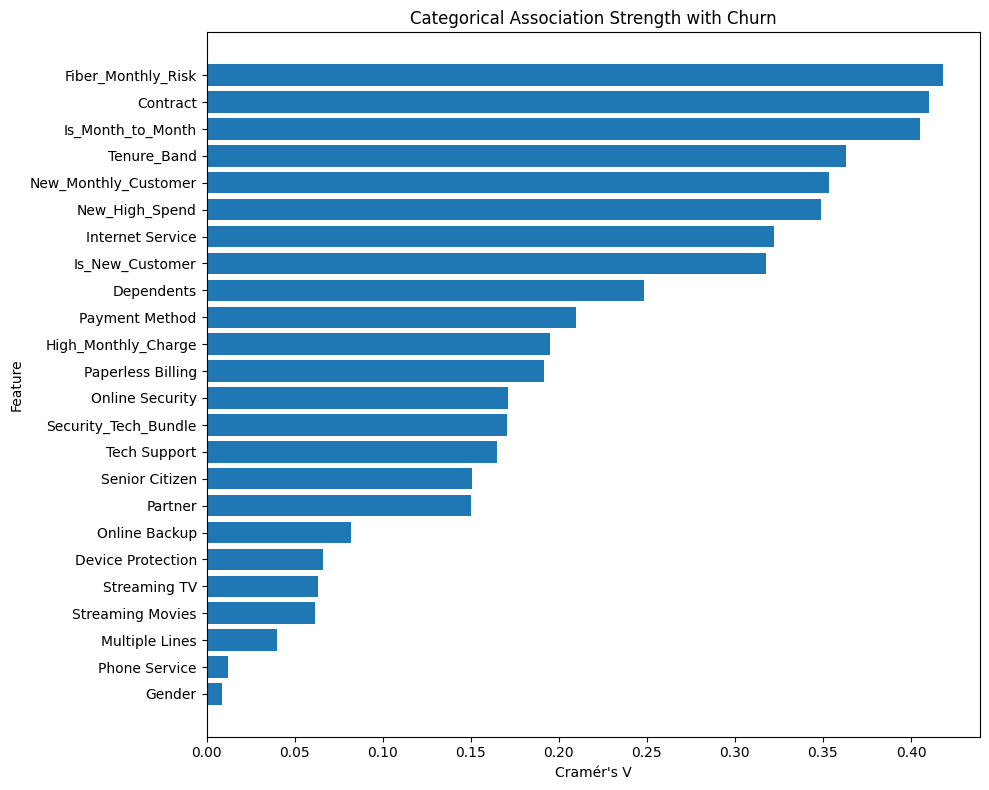

In [9]:
# 9. Plot Cramér's V ranking

plot_data = chi_square_results.sort_values("Cramers_V", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_data["Feature"], plot_data["Cramers_V"])
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.title("Categorical Association Strength with Churn")
plt.tight_layout()

plt.savefig(
    figures_dir / "cramers_v_feature_ranking.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# 5. Numerical variables vs churn

Two complementary tests are used:

- **Welch's t-test**: compares group means without assuming equal variances.
- **Mann–Whitney U test**: non-parametric confirmation based on the distributions/ranks.
- **Cohen's d**: effect-size measure for the difference between churned and retained customers.

Cohen's d is reported as:

`mean(churned) − mean(retained)` divided by pooled standard deviation.

Therefore, the sign indicates direction.

In [10]:
# 10. Numerical-test helper functions

def cohens_d(group1, group0):
    group1 = np.asarray(group1, dtype=float)
    group0 = np.asarray(group0, dtype=float)

    group1 = group1[~np.isnan(group1)]
    group0 = group0[~np.isnan(group0)]

    n1 = len(group1)
    n0 = len(group0)

    var1 = np.var(group1, ddof=1)
    var0 = np.var(group0, ddof=1)

    pooled_sd = np.sqrt(
        ((n1 - 1) * var1 + (n0 - 1) * var0)
        / (n1 + n0 - 2)
    )

    if pooled_sd == 0:
        return np.nan

    return (np.mean(group1) - np.mean(group0)) / pooled_sd


def interpret_cohens_d(value):
    value = abs(value)

    if pd.isna(value):
        return "Not available"
    if value < 0.20:
        return "Negligible"
    if value < 0.50:
        return "Small"
    if value < 0.80:
        return "Medium"
    return "Large" 

In [11]:
# 11. Run numerical statistical tests

numerical_rows = []

for feature in numerical_features:

    churned = df.loc[df["Churn Value"] == 1, feature].dropna()
    retained = df.loc[df["Churn Value"] == 0, feature].dropna()

    t_stat, t_p = ttest_ind(
        churned,
        retained,
        equal_var=False,
        nan_policy="omit"
    )

    u_stat, mw_p = mannwhitneyu(
        churned,
        retained,
        alternative="two-sided"
    )

    d = cohens_d(churned, retained)

    numerical_rows.append({
        "Feature": feature,
        "Churned_Mean": churned.mean(),
        "Retained_Mean": retained.mean(),
        "Mean_Difference_Churned_minus_Retained": churned.mean() - retained.mean(),
        "Churned_Median": churned.median(),
        "Retained_Median": retained.median(),
        "Welch_T_Statistic": t_stat,
        "Welch_T_P_Value": t_p,
        "Mann_Whitney_U": u_stat,
        "Mann_Whitney_P_Value": mw_p,
        "Cohens_D": d,
        "Effect_Size": interpret_cohens_d(d)
    })


numerical_test_results = pd.DataFrame(numerical_rows)

numerical_test_results["Welch_FDR_Adjusted_P_Value"] = bh_adjust(
    numerical_test_results["Welch_T_P_Value"].values
)

numerical_test_results["MW_FDR_Adjusted_P_Value"] = bh_adjust(
    numerical_test_results["Mann_Whitney_P_Value"].values
)

numerical_test_results["Welch_Significant_FDR_0.05"] = (
    numerical_test_results["Welch_FDR_Adjusted_P_Value"] < 0.05
)

numerical_test_results["MW_Significant_FDR_0.05"] = (
    numerical_test_results["MW_FDR_Adjusted_P_Value"] < 0.05
)

numerical_test_results = numerical_test_results.sort_values(
    by="Cohens_D",
    key=lambda s: s.abs(),
    ascending=False
).reset_index(drop=True)

display(numerical_test_results.round(6))

,Feature,Churned_Mean,Retained_Mean,Mean_Difference_Churned_minus_Retained,Churned_Median,Retained_Median,Welch_T_Statistic,Welch_T_P_Value,Mann_Whitney_U,Mann_Whitney_P_Value,Cohens_D,Effect_Size,Welch_FDR_Adjusted_P_Value,MW_FDR_Adjusted_P_Value,Welch_Significant_FDR_0.05,MW_Significant_FDR_0.05
0,Tenure Months,17.979133,37.569965,-19.590832,10.00,38.000,-34.823819,0.0,2515538.0,0.0,-0.852250,Large,0.0,0.0,True,True
1,Total Charges,1531.796094,2549.911442,-1018.115348,703.55,1679.525,-18.706618,0.0,3381224.0,0.0,-0.458213,Small,0.0,0.0,True,True
2,Monthly Charges,74.441332,61.265124,13.176209,79.65,64.425,18.407527,0.0,6003125.5,0.0,0.446283,Small,0.0,0.0,True,True
3,Support_Service_Count,0.895131,1.399497,-0.504366,1.00,1.000,-17.018479,0.0,3920604.5,0.0,-0.397906,Small,0.0,0.0,True,True


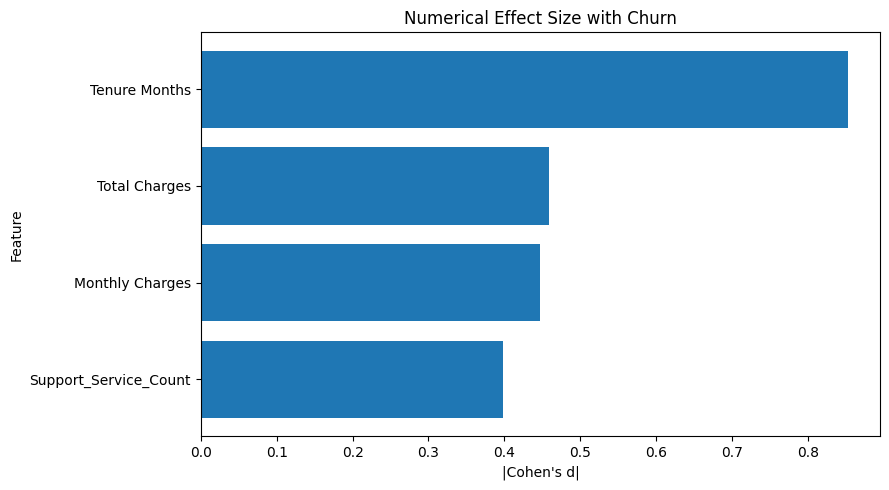

In [12]:
# 12. Plot numerical effect sizes

plot_data = numerical_test_results.copy()
plot_data["Absolute_Cohens_D"] = plot_data["Cohens_D"].abs()
plot_data = plot_data.sort_values("Absolute_Cohens_D", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_data["Feature"], plot_data["Absolute_Cohens_D"])
plt.xlabel("|Cohen's d|")
plt.ylabel("Feature")
plt.title("Numerical Effect Size with Churn")
plt.tight_layout()

plt.savefig(
    figures_dir / "cohens_d_numerical_features.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# 6. Correlation and multicollinearity analysis

Correlation is used to identify highly related numerical variables. VIF is then used to assess how strongly each encoded predictor can be explained by the remaining predictors.

Because some engineered features are deterministic transformations of existing variables, very high or infinite VIF values are expected in the **full candidate set**. This is useful evidence for feature-selection decisions.

In [13]:
# 13. Numeric correlation matrix

numeric_for_corr = df.select_dtypes(include=np.number)

correlation_matrix = numeric_for_corr.corr()

display(correlation_matrix.round(3))

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Is_New_Customer,Is_Month_to_Month,High_Monthly_Charge,Fiber_Monthly_Risk,New_High_Spend,New_Monthly_Customer,Support_Service_Count,Security_Tech_Bundle
Senior Citizen,1.000,0.016,-0.174,0.017,0.009,0.143,-0.039,0.067,0.059,-0.061,0.105,0.120,0.157,-0.034,0.220,0.103,0.151,-0.029,0.138,0.212,0.244,0.076,-0.005,0.012,-0.059
Partner,0.016,1.000,0.363,0.380,0.018,0.142,0.143,0.141,0.154,0.120,0.125,0.117,-0.015,0.160,0.097,0.318,-0.150,-0.303,-0.281,0.083,-0.116,-0.173,-0.312,0.202,0.133
Dependents,-0.174,0.363,1.000,0.131,0.001,-0.028,0.050,0.003,-0.022,0.029,-0.058,-0.073,-0.119,0.075,-0.144,0.031,-0.249,-0.114,-0.175,-0.126,-0.197,-0.133,-0.137,0.021,0.052
Tenure Months,0.017,0.380,0.131,1.000,0.008,0.332,0.327,0.360,0.361,0.324,0.280,0.286,0.006,0.397,0.248,0.826,-0.352,-0.755,-0.646,0.196,-0.290,-0.407,-0.714,0.496,0.335
Phone Service,0.009,0.018,0.001,0.008,1.000,0.280,-0.093,-0.052,-0.071,-0.096,-0.023,-0.033,0.017,-0.000,0.247,0.113,0.012,-0.008,-0.001,0.328,0.215,0.120,0.000,-0.112,-0.081
Multiple Lines,0.143,0.142,-0.028,0.332,0.280,1.000,0.098,0.202,0.201,0.101,0.257,0.259,0.164,0.113,0.490,0.469,0.040,-0.263,-0.088,0.479,0.200,0.031,-0.236,0.219,0.082
Online Security,-0.039,0.143,0.050,0.327,-0.093,0.098,1.000,0.284,0.275,0.355,0.176,0.187,-0.004,0.175,0.297,0.412,-0.171,-0.241,-0.247,0.156,-0.175,-0.132,-0.234,0.683,0.678
Online Backup,0.067,0.141,0.003,0.360,-0.052,0.202,0.284,1.000,0.304,0.294,0.282,0.275,0.127,0.148,0.442,0.509,-0.082,-0.267,-0.164,0.312,-0.027,-0.100,-0.246,0.685,0.255
Device Protection,0.059,0.154,-0.022,0.361,-0.071,0.201,0.275,0.304,1.000,0.333,0.391,0.402,0.104,0.162,0.483,0.522,-0.066,-0.273,-0.226,0.356,-0.036,-0.069,-0.259,0.696,0.276
Tech Support,-0.061,0.120,0.029,0.324,-0.096,0.101,0.355,0.294,0.333,1.000,0.278,0.279,0.038,0.182,0.338,0.432,-0.165,-0.238,-0.285,0.200,-0.195,-0.127,-0.233,0.709,0.672


In [14]:
# 14. Identify high-correlation pairs

high_corr_rows = []

corr_columns = correlation_matrix.columns

for i in range(len(corr_columns)):
    for j in range(i + 1, len(corr_columns)):
        value = float(correlation_matrix.iloc[i, j])

        if abs(value) >= 0.80:
            high_corr_rows.append({
                "Feature_1": corr_columns[i],
                "Feature_2": corr_columns[j],
                "Correlation": value
            })

high_correlation_pairs = pd.DataFrame(high_corr_rows)

if high_correlation_pairs.empty:
    print("No numeric pairs have |correlation| >= 0.80.")
else:
    display(
        high_correlation_pairs.sort_values(
            by="Correlation",
            key=lambda s: s.abs(),
            ascending=False
        ).round(4)
    )

,Feature_1,Feature_2,Correlation
2,Is_New_Customer,New_Monthly_Customer,0.9367
1,Monthly Charges,High_Monthly_Charge,0.8583
0,Tenure Months,Total Charges,0.8262


In [15]:
# 15. VIF helper function without requiring statsmodels

def calculate_vif(data, feature_list):
    working = data[feature_list].copy()

    # One-hot encode object/category variables and avoid the dummy-variable trap.
    X = pd.get_dummies(
        working,
        drop_first=True,
        dtype=float
    )

    # Remove constant columns if any.
    X = X.loc[:, X.nunique(dropna=False) > 1]

    # Fill any unexpected missing values with medians.
    for col in X.columns:
        if X[col].isnull().any():
            X[col] = X[col].fillna(X[col].median())

    values = X.to_numpy(dtype=float)

    vif_rows = []

    for i, feature in enumerate(X.columns):
        y = values[:, i]
        X_other = np.delete(values, i, axis=1)

        if X_other.shape[1] == 0:
            vif_value = 1.0
        else:
            model = LinearRegression()
            model.fit(X_other, y)
            r_squared = model.score(X_other, y)

            if r_squared >= 0.999999:
                vif_value = np.inf
            else:
                vif_value = 1.0 / (1.0 - r_squared)

        vif_rows.append({
            "Encoded_Feature": feature,
            "VIF": vif_value
        })

    return (
        pd.DataFrame(vif_rows)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

In [16]:
# 16. VIF for the full candidate set

all_predictor_features = [
    col for col in df.columns
    if col != "Churn Value"
]

vif_full_results = calculate_vif(
    df,
    all_predictor_features
)

display(vif_full_results.head(25).round(3))

,Encoded_Feature,VIF
0,Online Backup,inf
1,Tenure_Band_49+,inf
2,Device Protection,inf
3,Online Security,inf
4,Tech Support,inf
5,Is_New_Customer,inf
6,Contract_One year,inf
7,Support_Service_Count,inf
8,Is_Month_to_Month,inf
9,Tenure_Band_25-48,inf


### Proposed core feature representation

The following core set removes obvious deterministic helper features such as `Tenure_Band`, `Is_New_Customer`, `Is_Month_to_Month`, `High_Monthly_Charge`, and `Support_Service_Count` when their source variables are retained.

The engineered **interaction** features are retained as candidates because they may capture combinations of risk not represented by a single raw variable.

In [17]:
# 17. Proposed core feature set for VIF review

core_feature_candidates = [
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "Fiber_Monthly_Risk",
    "New_High_Spend",
    "New_Monthly_Customer",
    "Security_Tech_Bundle"
]

core_feature_candidates = [
    col for col in core_feature_candidates
    if col in df.columns
]

vif_core_results = calculate_vif(
    df,
    core_feature_candidates
)

display(vif_core_results.round(3))

,Encoded_Feature,VIF
0,Monthly Charges,37.069
1,Total Charges,18.021
2,Internet Service_Fiber optic,12.379
3,Tenure Months,10.886
4,Fiber_Monthly_Risk,6.205
5,Internet Service_No,4.842
6,New_Monthly_Customer,3.560
7,Contract_Two year,3.540
8,Security_Tech_Bundle,3.325
9,New_High_Spend,2.867


### VIF interpretation

Common screening guidance:

- **VIF < 5:** generally low/moderate concern
- **VIF 5–10:** investigate
- **VIF > 10:** high multicollinearity concern
- **Infinite VIF:** exact or near-exact linear dependence

A high VIF does not automatically mean a feature must be removed. For Group 4, regularized models, tree-based models, and cross-validation can be used to evaluate whether predictive performance improves when correlated business features are retained.

# 7. Mutual Information feature ranking

In [18]:
# 18. Calculate Mutual Information for each original feature

predictor_features = [
    col for col in df.columns
    if col != "Churn Value"
]

X_mi = df[predictor_features].copy()

discrete_mask = []

for col in predictor_features:

    is_discrete = (
        str(X_mi[col].dtype) in ["object", "category", "bool"]
        or X_mi[col].nunique(dropna=True) <= 10
    )

    discrete_mask.append(is_discrete)

    if str(X_mi[col].dtype) in ["object", "category"]:
        X_mi[col] = (
            X_mi[col]
            .astype("category")
            .cat.codes
        )

X_mi = X_mi.apply(pd.to_numeric)

for col in X_mi.columns:
    if X_mi[col].isnull().any():
        X_mi[col] = X_mi[col].fillna(X_mi[col].median())

mi_scores = mutual_info_classif(
    X_mi,
    df["Churn Value"],
    discrete_features=discrete_mask,
    random_state=42
)

mutual_information_results = pd.DataFrame({
    "Feature": predictor_features,
    "Mutual_Information": mi_scores
}).sort_values(
    "Mutual_Information",
    ascending=False
).reset_index(drop=True)

display(mutual_information_results.round(6))

,Feature,Mutual_Information
0,Contract,0.098453
1,Is_Month_to_Month,0.091887
2,Fiber_Monthly_Risk,0.083017
3,Tenure Months,0.074387
4,Tenure_Band,0.066332
5,New_Monthly_Customer,0.058663
6,Internet Service,0.055574
7,New_High_Spend,0.053103
8,Is_New_Customer,0.048063
9,Monthly Charges,0.046960


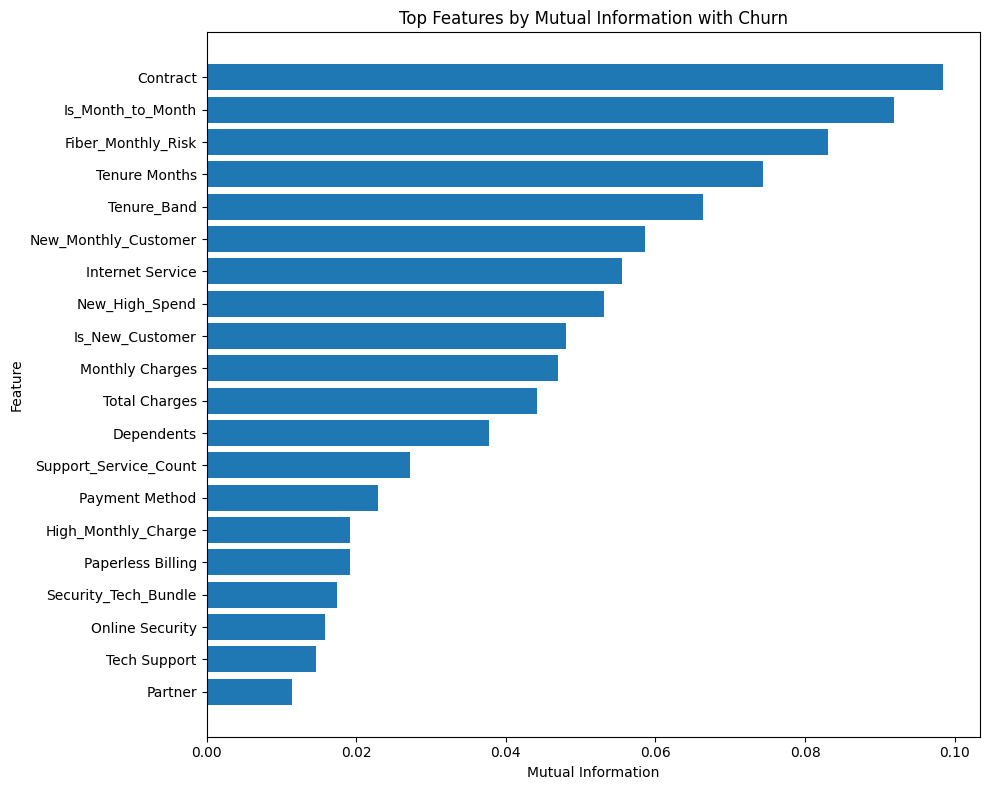

In [19]:
# 19. Plot top Mutual Information features

mi_plot = mutual_information_results.head(20).sort_values(
    "Mutual_Information",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(mi_plot["Feature"], mi_plot["Mutual_Information"])
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Top Features by Mutual Information with Churn")
plt.tight_layout()

plt.savefig(
    figures_dir / "mutual_information_feature_ranking.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# 8. Feature-selection results

The final recommendation combines:

1. Business relevance
2. Statistical evidence
3. Effect size / association strength
4. Mutual Information
5. Redundancy and multicollinearity
6. Leakage prevention

Some deterministic engineered helper features remain valuable for BI/segmentation but are not placed in the default Group 4 core model together with their source variables.

In [20]:
# 20. Combine evidence into a feature-selection table

mi_lookup = dict(
    zip(
        mutual_information_results["Feature"],
        mutual_information_results["Mutual_Information"]
    )
)

chi_lookup = (
    chi_square_results
    .set_index("Feature")
    .to_dict("index")
)

num_lookup = (
    numerical_test_results
    .set_index("Feature")
    .to_dict("index")
)


# Default Group 4 core model recommendations
recommended_core_features = [
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "Fiber_Monthly_Risk",
    "New_High_Spend",
    "New_Monthly_Customer",
    "Security_Tech_Bundle"
]

# Useful for BI/segmentation or alternative model specifications,
# but redundant with retained source variables in the default core set.
optional_engineered_features = [
    "Is_New_Customer",
    "Tenure_Band",
    "Is_Month_to_Month",
    "High_Monthly_Charge",
    "Support_Service_Count"
]

# Weak standalone statistical relationship in this dataset.
low_priority_features = [
    "Gender",
    "Phone Service"
]

selection_rows = []

for feature in predictor_features:

    if feature in recommended_core_features:
        recommendation = "Keep - Core"
        reason = "Retained based on statistical/business relevance and/or useful interaction information."

    elif feature in optional_engineered_features:
        recommendation = "Optional / BI"
        reason = (
            "Useful engineered segmentation feature, but derived from a source variable already "
            "retained in the core model; avoid unnecessary redundancy in linear models."
        )

    elif feature in low_priority_features:
        recommendation = "Low Priority"
        reason = "Weak or non-significant standalone association with churn in this dataset."

    else:
        recommendation = "Review"
        reason = "Review with Group 4 cross-validation before final model inclusion."

    row = {
        "Feature": feature,
        "Recommendation": recommendation,
        "Selection_Reason": reason,
        "Mutual_Information": mi_lookup.get(feature, np.nan),
        "Statistical_Test": "",
        "Adjusted_P_Value": np.nan,
        "Effect_Size_Value": np.nan,
        "Effect_Size_Type": ""
    }

    if feature in chi_lookup:
        evidence = chi_lookup[feature]
        row["Statistical_Test"] = "Chi-square"
        row["Adjusted_P_Value"] = evidence["FDR_Adjusted_P_Value"]
        row["Effect_Size_Value"] = evidence["Cramers_V"]
        row["Effect_Size_Type"] = "Cramer's V"

    elif feature in num_lookup:
        evidence = num_lookup[feature]
        row["Statistical_Test"] = "Welch t-test + Mann-Whitney U"
        row["Adjusted_P_Value"] = evidence["Welch_FDR_Adjusted_P_Value"]
        row["Effect_Size_Value"] = evidence["Cohens_D"]
        row["Effect_Size_Type"] = "Cohen's d"

    selection_rows.append(row)


feature_selection_results = pd.DataFrame(selection_rows)

recommendation_order = {
    "Keep - Core": 0,
    "Optional / BI": 1,
    "Low Priority": 2,
    "Review": 3
}

feature_selection_results["_order"] = (
    feature_selection_results["Recommendation"]
    .map(recommendation_order)
    .fillna(99)
)

feature_selection_results = (
    feature_selection_results
    .sort_values(
        ["_order", "Mutual_Information"],
        ascending=[True, False]
    )
    .drop(columns=["_order"])
    .reset_index(drop=True)
)

display(feature_selection_results.round(6))

,Feature,Recommendation,Selection_Reason,Mutual_Information,Statistical_Test,Adjusted_P_Value,Effect_Size_Value,Effect_Size_Type
0,Contract,Keep - Core,Retained based on statistical/business relevan...,0.098453,Chi-square,0.000000,0.410116,Cramer's V
1,Fiber_Monthly_Risk,Keep - Core,Retained based on statistical/business relevan...,0.083017,Chi-square,0.000000,0.418292,Cramer's V
2,Tenure Months,Keep - Core,Retained based on statistical/business relevan...,0.074387,Welch t-test + Mann-Whitney U,0.000000,-0.852250,Cohen's d
3,New_Monthly_Customer,Keep - Core,Retained based on statistical/business relevan...,0.058663,Chi-square,0.000000,0.353224,Cramer's V
4,Internet Service,Keep - Core,Retained based on statistical/business relevan...,0.055574,Chi-square,0.000000,0.322455,Cramer's V
5,New_High_Spend,Keep - Core,Retained based on statistical/business relevan...,0.053103,Chi-square,0.000000,0.349027,Cramer's V
6,Monthly Charges,Keep - Core,Retained based on statistical/business relevan...,0.046960,Welch t-test + Mann-Whitney U,0.000000,0.446283,Cohen's d
7,Total Charges,Keep - Core,Retained based on statistical/business relevan...,0.044180,Welch t-test + Mann-Whitney U,0.000000,-0.458213,Cohen's d
8,Dependents,Keep - Core,Retained based on statistical/business relevan...,0.037746,Chi-square,0.000000,0.248542,Cramer's V
9,Payment Method,Keep - Core,Retained based on statistical/business relevan...,0.022886,Chi-square,0.000000,0.209902,Cramer's V


# 9. Final feature list for Group 4

In [21]:
# 21. Prepare final feature list

final_feature_list = [
    feature
    for feature in recommended_core_features
    if feature in df.columns
]

print("TARGET:")
print("- Churn Value")

print("\nRECOMMENDED CORE FEATURES:")
for feature in final_feature_list:
    print("-", feature)

print("\nOPTIONAL ENGINEERED / BI FEATURES:")
for feature in optional_engineered_features:
    if feature in df.columns:
        print("-", feature)

print("\nLOW-PRIORITY FEATURES:")
for feature in low_priority_features:
    if feature in df.columns:
        print("-", feature)

TARGET:
- Churn Value

RECOMMENDED CORE FEATURES:
- Senior Citizen
- Partner
- Dependents
- Tenure Months
- Multiple Lines
- Internet Service
- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies
- Contract
- Paperless Billing
- Payment Method
- Monthly Charges
- Total Charges
- Fiber_Monthly_Risk
- New_High_Spend
- New_Monthly_Customer
- Security_Tech_Bundle

OPTIONAL ENGINEERED / BI FEATURES:
- Is_New_Customer
- Tenure_Band
- Is_Month_to_Month
- High_Monthly_Charge
- Support_Service_Count

LOW-PRIORITY FEATURES:
- Gender
- Phone Service


## Group 4 handoff notes

- **Target:** `Churn Value`
- Do **not** reintroduce `Churn Label`, `Churn Score`, or `Churn Reason`.
- `Zip Code` was excluded from the Group 3 predictive feature set.
- `Total Frequency` was removed because it is an exact sum of individual service indicators.
- `CLTV` was removed because it is almost perfectly correlated with `Total Charges`.
- Fit all preprocessing/scaling **only on the training data** inside the Group 4 ML pipeline.
- Use one-hot encoding for categorical variables such as `Internet Service` and `Contract`.
- For linear/logistic models, pay attention to VIF and consider regularization.
- For tree-based models, correlated features are less problematic, but feature importance should still be interpreted carefully.
- Compare the core set against optional engineered features using cross-validation rather than assuming every engineered feature improves prediction.


# 10. Create statistical findings summary

In [22]:
# 22. Build a concise statistical findings table

findings_rows = []

# Top categorical findings
for _, row in chi_square_results.head(10).iterrows():
    findings_rows.append({
        "Feature": row["Feature"],
        "Analysis_Type": "Categorical",
        "Statistical_Test": "Chi-square",
        "Adjusted_P_Value": row["FDR_Adjusted_P_Value"],
        "Effect_Size": row["Cramers_V"],
        "Effect_Size_Measure": "Cramer's V",
        "Finding": (
            f"{row['Association_Strength']} association with churn "
            f"(Cramer's V = {row['Cramers_V']:.3f})."
        )
    })

# Numerical findings
for _, row in numerical_test_results.iterrows():
    direction = (
        "higher among churned customers"
        if row["Mean_Difference_Churned_minus_Retained"] > 0
        else "lower among churned customers"
    )

    findings_rows.append({
        "Feature": row["Feature"],
        "Analysis_Type": "Numerical",
        "Statistical_Test": "Welch t-test + Mann-Whitney U",
        "Adjusted_P_Value": row["Welch_FDR_Adjusted_P_Value"],
        "Effect_Size": row["Cohens_D"],
        "Effect_Size_Measure": "Cohen's d",
        "Finding": (
            f"Values are {direction}; "
            f"{row['Effect_Size'].lower()} effect "
            f"(Cohen's d = {row['Cohens_D']:.3f})."
        )
    })

statistical_findings = pd.DataFrame(findings_rows)

display(statistical_findings.round(6))

,Feature,Analysis_Type,Statistical_Test,Adjusted_P_Value,Effect_Size,Effect_Size_Measure,Finding
0,Fiber_Monthly_Risk,Categorical,Chi-square,0.0,0.418292,Cramer's V,Strong association with churn (Cramer's V = 0....
1,Contract,Categorical,Chi-square,0.0,0.410116,Cramer's V,Strong association with churn (Cramer's V = 0....
2,Is_Month_to_Month,Categorical,Chi-square,0.0,0.405103,Cramer's V,Strong association with churn (Cramer's V = 0....
3,Tenure_Band,Categorical,Chi-square,0.0,0.362859,Cramer's V,Moderate association with churn (Cramer's V = ...
4,New_Monthly_Customer,Categorical,Chi-square,0.0,0.353224,Cramer's V,Moderate association with churn (Cramer's V = ...
5,New_High_Spend,Categorical,Chi-square,0.0,0.349027,Cramer's V,Moderate association with churn (Cramer's V = ...
6,Internet Service,Categorical,Chi-square,0.0,0.322455,Cramer's V,Moderate association with churn (Cramer's V = ...
7,Is_New_Customer,Categorical,Chi-square,0.0,0.317580,Cramer's V,Moderate association with churn (Cramer's V = ...
8,Dependents,Categorical,Chi-square,0.0,0.248542,Cramer's V,Moderate association with churn (Cramer's V = ...
9,Payment Method,Categorical,Chi-square,0.0,0.209902,Cramer's V,Moderate association with churn (Cramer's V = ...


# 11. Save Group 3 deliverables

In [23]:
# 23. Save statistical-analysis outputs

chi_square_results.to_csv(
    output_dir / "categorical_chi_square_results.csv",
    index=False
)

category_churn_rates.to_csv(
    output_dir / "categorical_churn_rates.csv",
    index=False
)

numerical_test_results.to_csv(
    output_dir / "numerical_statistical_test_results.csv",
    index=False
)

high_correlation_pairs.to_csv(
    output_dir / "statistical_high_correlation_pairs.csv",
    index=False
)

vif_full_results.to_csv(
    output_dir / "vif_full_candidate_results.csv",
    index=False
)

vif_core_results.to_csv(
    output_dir / "vif_core_feature_results.csv",
    index=False
)

mutual_information_results.to_csv(
    output_dir / "mutual_information_results.csv",
    index=False
)

feature_selection_results.to_csv(
    output_dir / "feature_selection_results.csv",
    index=False
)

statistical_findings.to_csv(
    output_dir / "statistical_findings.csv",
    index=False
)

final_feature_text = [
    "Customer Churn Prediction & Business Intelligence System",
    "Group 3 - Final Feature List",
    "",
    "TARGET:",
    "Churn Value",
    "",
    "RECOMMENDED CORE FEATURES:"
]

final_feature_text.extend(
    [f"- {feature}" for feature in final_feature_list]
)

final_feature_text.extend([
    "",
    "OPTIONAL ENGINEERED / BI FEATURES:"
])

final_feature_text.extend(
    [
        f"- {feature}"
        for feature in optional_engineered_features
        if feature in df.columns
    ]
)

final_feature_text.extend([
    "",
    "LOW-PRIORITY FEATURES:"
])

final_feature_text.extend(
    [
        f"- {feature}"
        for feature in low_priority_features
        if feature in df.columns
    ]
)

final_feature_text.extend([
    "",
    "IMPORTANT HANDOFF NOTES:",
    "- Do not use Churn Label, Churn Score, or Churn Reason as predictors.",
    "- Total Frequency was removed as a perfectly redundant service-count feature.",
    "- CLTV was removed due to near-perfect correlation with Total Charges.",
    "- Fit encoding/scaling on training data only inside the Group 4 ML pipeline.",
    "- Evaluate optional engineered features with cross-validation."
])

with open(
    output_dir / "final_feature_list.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write("\n".join(final_feature_text))

print("All statistical-analysis and feature-selection outputs saved successfully.")
print("Output folder:", output_dir)

All statistical-analysis and feature-selection outputs saved successfully.
Output folder: D:\DS intern\Task\Group\Week 05\Customer-Churn-Prediction-Business-Intelligence-System\Feature Engineering & Statistical Analysis\outputs


# 12. Final statistical summary

In [24]:
# 24. Print final summary

strongest_categorical = chi_square_results.iloc[0]

largest_numeric_effect = (
    numerical_test_results
    .iloc[
        numerical_test_results["Cohens_D"]
        .abs()
        .argmax()
    ]
)

print("=" * 72)
print("STATISTICAL ANALYSIS & FEATURE SELECTION COMPLETED")
print("=" * 72)

print(f"Rows analyzed: {df.shape[0]:,}")
print(f"Categorical variables tested: {len(categorical_features)}")
print(f"Numerical variables tested  : {len(numerical_features)}")

print("\nStrongest categorical association:")
print(
    f"- {strongest_categorical['Feature']} "
    f"(Cramer's V = {strongest_categorical['Cramers_V']:.3f})"
)

print("\nLargest numerical effect:")
print(
    f"- {largest_numeric_effect['Feature']} "
    f"(Cohen's d = {largest_numeric_effect['Cohens_D']:.3f})"
)

print(f"\nRecommended core features for Group 4: {len(final_feature_list)}")

print("\nMain deliverables created:")
print("- categorical_chi_square_results.csv")
print("- numerical_statistical_test_results.csv")
print("- vif_full_candidate_results.csv")
print("- vif_core_feature_results.csv")
print("- mutual_information_results.csv")
print("- feature_selection_results.csv")
print("- statistical_findings.csv")
print("- final_feature_list.txt")

print("\nNext step: review these results, then commit and push the completed Group 3 work.")

STATISTICAL ANALYSIS & FEATURE SELECTION COMPLETED
Rows analyzed: 7,043
Categorical variables tested: 24
Numerical variables tested  : 4

Strongest categorical association:
- Fiber_Monthly_Risk (Cramer's V = 0.418)

Largest numerical effect:
- Tenure Months (Cohen's d = -0.852)

Recommended core features for Group 4: 21

Main deliverables created:
- categorical_chi_square_results.csv
- numerical_statistical_test_results.csv
- vif_full_candidate_results.csv
- vif_core_feature_results.csv
- mutual_information_results.csv
- feature_selection_results.csv
- statistical_findings.csv
- final_feature_list.txt

Next step: review these results, then commit and push the completed Group 3 work.
